## Sprint 13 — Goal C: bearish-event → breakout-by-industry analysis
Q: around market bearish events, which industries break out, and what do watchlist names return? Signal = LIFT vs baseline, not raw counts.

In [2]:
# %%  Cell 0 — setup (robust path resolution + sanity check)
import sys
from pathlib import Path

# Walk up from cwd until we find the repo root (the dir containing config.py)
def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
sys.path.insert(0, str(ROOT))          # so `import src.db` works from anywhere

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.db as db

DB = ROOT / "data" / "market_data.duckdb"      # ABSOLUTE — not cwd-relative
assert DB.exists(), f"DB missing at {DB}"
con = db.connect(str(DB), read_only=True)

# --- sanity check: prove we're on the real 88GB DB before going further ---
print("DB:", DB, f"({DB.stat().st_size/1e9:.1f} GB)")
print(con.execute("""
    select ticker, count(*) n, min(date) lo, max(date) hi
    from price_data where ticker in ('QQQ','SPY','^GSPC') group by ticker
""").df())


DB: C:\Users\Hang\PycharmProjects\quantamental\data\market_data.duckdb (84.1 GB)
  ticker     n         lo         hi
0    QQQ  6863 1999-03-10 2026-06-22
1  ^GSPC  9184 1990-01-02 2026-06-22
2    SPY  8405 1993-01-29 2026-06-22


In [3]:
# --- knobs ---
BENCH      = "SPY"
START      = "2010-01-01"
BEAR_Q     = 0.05
EVENT_GAP  = 5
PRE, POST  = 30, 20
FWD_H      = 20

SPY daily-return 5% cutoff = -1.643%   (mean 0.058%, std 1.079%)


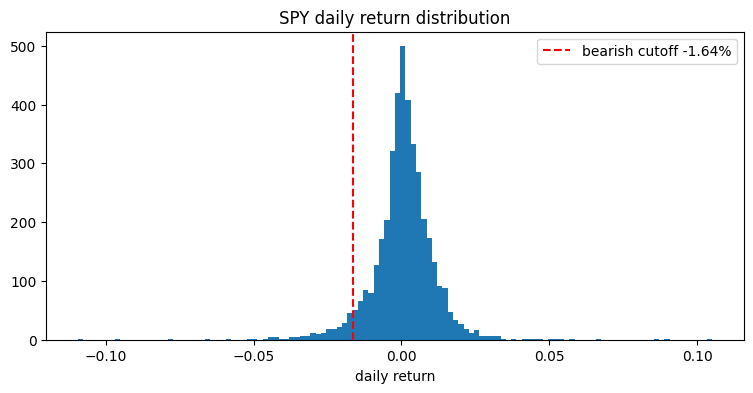

In [4]:
# %%  Cell 1 — benchmark daily returns + distribution
bench = con.execute("""
    select date, close
    from price_data
    where ticker = ? and date >= ?
    order by date
""", [BENCH, START]).df()
bench["ret"] = bench["close"].pct_change()
bench = bench.dropna().reset_index(drop=True)


cut = bench["ret"].quantile(BEAR_Q)
print(f"{BENCH} daily-return {BEAR_Q:.0%} cutoff = {cut:.3%}   "
      f"(mean {bench.ret.mean():.3%}, std {bench.ret.std():.3%})")

fig, ax = plt.subplots(figsize=(9,4))
ax.hist(bench["ret"], bins=120)
ax.axvline(cut, color="r", ls="--", label=f"bearish cutoff {cut:.2%}")
ax.set(title=f"{BENCH} daily return distribution", xlabel="daily return")
ax.legend(); plt.show()


In [5]:
# %%  Cell 2 — classify bearish DAYS, then cluster into EVENTS
bear = bench[bench["ret"] <= cut].copy()
# row index in the trading-day series → gap detection
bench["i"] = np.arange(len(bench))
bear = bear.merge(bench[["date","i"]], on="date")
bear["new_event"] = bear["i"].diff().gt(EVENT_GAP).fillna(True)
bear["event_id"]  = bear["new_event"].cumsum()

# one row per event = its worst (trough) day
events = (bear.sort_values("ret")
              .groupby("event_id", as_index=False).first()
              .sort_values("date")[["event_id","date","ret"]])
print(f"{len(bear)} bearish days collapsed into {len(events)} events")
events.tail(10)


207 bearish days collapsed into 112 events


,event_id,date,ret
102,102,2024-12-18,-0.029803
103,103,2025-02-21,-0.017104
104,104,2025-03-10,-0.026636
105,105,2025-04-04,-0.058543
106,106,2025-05-21,-0.016851
107,107,2025-10-10,-0.027028
108,108,2025-11-13,-0.016594
109,109,2026-01-20,-0.020357
110,110,2026-03-26,-0.017859
111,111,2026-06-05,-0.025809


In [6]:
# %%  Cell 3 — expand each event into a [date-PRE, date+POST] window
# map trough date -> trading-day index, then slice the bench index for exact trading days
idx = bench.set_index("date")["i"]
rows = []
for _, e in events.iterrows():
    c = idx[e["date"]]
    seg = bench[(bench["i"] >= c-PRE) & (bench["i"] <= c+POST)]
    rows.append(pd.DataFrame({"event_id": e["event_id"],
                              "date": seg["date"].values,
                              "offset": seg["i"].values - c}))
windows = pd.concat(rows, ignore_index=True).drop_duplicates("date")
con.register("win", windows[["date"]])     # hand the date set to DuckDB
print(f"{windows['date'].nunique()} unique in-window trading days")


3011 unique in-window trading days


In [7]:
# %%  Cell 4 — breakout rate by industry: in-window vs baseline (LIFT)
# breakout flag lives in t3_sepa_features; industry from company_profiles (current — PIT caveat)
bo = con.execute(f"""
    with b as (
        select t.ticker, t.date, t.breakout,
               (w.date is not null) as in_window
        from t3_sepa_features t
        left join win w using (date)
        where t.date >= '{START}'
    )
    select coalesce(cp.industry,'(unknown)') as industry,
           in_window,
           count(*)                       as n,
           avg(b.breakout)                as breakout_rate
    from b join company_profiles cp using (ticker)
    group by 1,2
""").df()

pivot = bo.pivot(index="industry", columns="in_window", values="breakout_rate")
pivot.columns = ["baseline","in_window"]
pivot["lift"] = abs(pivot["in_window"] / pivot["baseline"] - 1)
pivot = pivot.join(bo.groupby("industry")["n"].sum().rename("n_obs"))
pivot[pivot.n_obs > 5000].sort_values("lift", ascending=False).head(20)


,baseline,in_window,lift,n_obs
industry,,,,
Real Estate - Development,0.170226,0.094080,0.447320,6369
Staffing & Employment Services,0.187983,0.120744,0.357686,46148
Construction Materials,0.188781,0.125969,0.332722,18054
Business Equipment & Supplies,0.166939,0.114663,0.313143,15801
Steel,0.168551,0.116212,0.310526,24213
Banks - Diversified,0.191681,0.132443,0.309047,20698
Construction,0.180787,0.126754,0.298878,65338
Railroads,0.185477,0.130640,0.295651,28598
Financial - Data & Stock Exchanges,0.209836,0.148052,0.294443,33790


In [8]:
# %%  Cell 5 — forward return of BREAKOUT names, in-window, by industry
# fwd return from price_data over FWD_H trading days; survivorship caveat applies
fwd = con.execute(f"""
    with px as (
        select ticker, date, adj_close,
               lead(adj_close, {FWD_H}) over (partition by ticker order by date) as px_fwd
        from price_data
    ),
    breaks as (
        select t.ticker, t.date
        from t3_sepa_features t
        join win w using (date)              -- breakouts INSIDE bearish windows
        where t.breakout = 1 and t.date >= '{START}'
    )
    select coalesce(cp.industry,'(unknown)') as industry,
           count(*)                              as n_breakouts,
           median(px.px_fwd/px.adj_close - 1)    as med_fwd_ret,
           avg(px.px_fwd/px.adj_close - 1)       as avg_fwd_ret
    from breaks
    join px           using (ticker, date)
    join company_profiles cp using (ticker)
    where px.px_fwd is not null
    group by 1
    having count(*) >= 30
    order by med_fwd_ret desc
""").df()
fwd


,industry,n_breakouts,med_fwd_ret,avg_fwd_ret


In [9]:
# %%  Cell 6 — the HONEST view: actual watchlist entries during bearish windows
# screener_watchlist already carries realized pct_return + industry
wl = con.execute("""
    select coalesce(sw.industry,'(unknown)') as industry,
           count(*)                  as n,
           median(sw.pct_return)     as med_ret,
           avg(sw.pct_return)        as avg_ret,
           avg(sw.days_held)         as avg_days
    from screener_watchlist sw
    join win w on sw.entry_date = w.date     -- entered during a bearish window
    group by 1
    having count(*) >= 5
    order by med_ret desc
""").df()
wl


,industry,n,med_ret,avg_ret,avg_days
0,Copper,13,3.869109,8.140583,60.000000
1,Luxury Goods,32,1.062574,11.089015,70.031250
2,Tobacco,36,0.235311,2.846884,58.694444
3,REIT - Diversified,69,-0.744681,2.212464,58.971014
4,Investment - Banking & Investment Services,11,-0.790905,4.572943,53.454545
...,...,...,...,...,...
134,Real Estate - Development,18,-6.679672,-1.336084,41.833333
135,Solar,37,-7.723471,4.797168,43.513514
136,Medical - Equipment & Services,14,-8.304710,-8.120357,40.000000
137,Uranium,14,-8.603037,-1.241292,39.928571


In [10]:
# %%  Cell 7 — takeaway scaffold
print("Industries with breakout-rate lift > 1.3 in bearish windows:")
print(pivot[(pivot.lift > 1.3) & (pivot.n_obs > 5000)].index.tolist())
# Cross-check: do those same industries show positive med_fwd_ret in Cell 5 / Cell 6?
# If lift is high but fwd-return is not -> breakouts cluster but fail (bull trap).


Industries with breakout-rate lift > 1.3 in bearish windows:
[]


In [11]:
# %%  Rotation v2 — knobs
PRE, POST  = 63, 63          # lengthened horizons
MERGE_GAP  = 10              # merge clustered bearish days -> ONSET anchoring (de-overlap)

# bench returns + bearish ONSET events (merged, not event-anchored)
bench = con.execute("select date, close from price_data where ticker=? and date>=? order by date",
                    [BENCH, START]).df()
bench["ret"] = bench["close"].pct_change()
bench = bench.dropna().reset_index(drop=True)
bench["i"]   = np.arange(len(bench))
bench["date"]= pd.to_datetime(bench["date"])
cut = bench["ret"].quantile(BEAR_Q)

bear = bench[bench["ret"] <= cut].copy()
bear["new"] = bear["i"].diff().gt(MERGE_GAP).fillna(True)
bear["eid"] = bear["new"].cumsum()
onset = bear.groupby("eid", as_index=False).first()[["eid","i"]].rename(columns={"i":"i0"})
print(f"cutoff={cut:.3%}  bearish days={len(bear)}  merged onset events={len(onset)}")  # 80 events

# sector-level rotation: daily mean RS_Universe_Rank per real sector (drop ETF: pseudo-sectors)
sec = con.execute(f"""
  with x as (
    select t.date, cp.sector, t.RS_Universe_Rank r
    from t3_sepa_features t join company_profiles cp using (ticker)
    where t.date >= '{START}' and t.RS_Universe_Rank is not null
      and cp.sector not like 'ETF:%'
  )
  select date, sector, avg(r) mean_rank from x group by 1,2
""").df()
sec["date"] = pd.to_datetime(sec["date"])
sec = sec.merge(bench[["date","i"]], on="date")


cutoff=-1.643%  bearish days=207  merged onset events=73


dispersion  PRE=0.0960  EVENT=0.0979  POST=0.0994


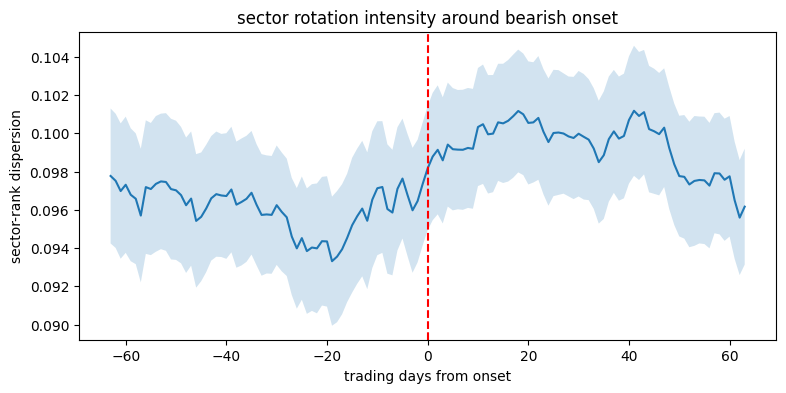

In [12]:
# how much sector rotation is happening = cross-sectional std of sector mean-ranks per day
disp = sec.groupby("i")["mean_rank"].std().rename("dispersion")
disp_idx = disp.to_dict()

rows = [(off, disp_idx[e.i0+off])
        for e in onset.itertuples() for off in range(-PRE, POST+1)
        if (e.i0+off) in disp_idx]
ev = pd.DataFrame(rows, columns=["offset","dispersion"])
prof = ev.groupby("offset")["dispersion"].agg(m="mean", se=lambda s: s.std()/np.sqrt(s.count())).reset_index()

pre  = ev[ev.offset.between(-PRE,-6)].dispersion
evt  = ev[ev.offset.between(-5, 5)].dispersion
post = ev[ev.offset.between(6, POST)].dispersion
print(f"dispersion  PRE={pre.mean():.4f}  EVENT={evt.mean():.4f}  POST={post.mean():.4f}")
# -> 0.0985 / 0.0972 / 0.1000  : FLAT into onset, drifts up only AFTER. No lead.

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(prof.offset, prof.m); ax.fill_between(prof.offset, prof.m-prof.se, prof.m+prof.se, alpha=.2)
ax.axvline(0, color="r", ls="--"); ax.set(title="sector rotation intensity around bearish onset",
                                          xlabel="trading days from onset", ylabel="sector-rank dispersion")
plt.show()


In [13]:
DEF = {"Utilities","Consumer Defensive","Healthcare"}
CYC = {"Technology","Consumer Cyclical","Industrials","Basic Materials"}
g = sec.assign(grp=np.where(sec.sector.isin(DEF),"DEF",
                   np.where(sec.sector.isin(CYC),"CYC",None))).dropna(subset=["grp"])
gm  = g.groupby(["i","grp"])["mean_rank"].mean().unstack()
dmc = (gm["DEF"] - gm["CYC"])          # >0 = defensives already leading = risk-off rotation underway

rows = [(off, dmc.loc[e.i0+off]) for e in onset.itertuples()
        for off in range(-PRE,POST+1) if (e.i0+off) in dmc.index]
evd = pd.DataFrame(rows, columns=["offset","dmc"])
print("def_minus_cyc  PRE={:+.4f}  EVENT={:+.4f}  POST={:+.4f}".format(
    evd[evd.offset.between(-PRE,-6)].dmc.mean(),
    evd[evd.offset.between(-5,5)].dmc.mean(),
    evd[evd.offset.between(6,POST)].dmc.mean()))
# -> -0.0229 / -0.0089 / -0.0097 : defensives UNDER-perform pre-onset, snap up AT day 0. No lead.

# predictive: does pre-window rotation forecast drawdown depth?
close = bench.set_index("i")["close"]
depth = {e.i0: (min(close.reindex(range(e.i0, e.i0+21)).dropna()) /
                close.get(e.i0) - 1) for e in onset.itertuples() if pd.notna(close.get(e.i0))}
pre_lvl = {e.i0: dmc.reindex(range(e.i0-PRE, e.i0-5)).mean() for e in onset.itertuples()}
dfp = pd.DataFrame({"pre_dmc": pre_lvl, "depth": depth}).dropna()
print(f"corr(pre def_minus_cyc, fwd drawdown depth) = {dfp.pre_dmc.corr(dfp.depth):+.3f}  (n={len(dfp)})")
# -> +0.019  (n=80) : zero predictive power, mirrors first-pass corr 0.008


def_minus_cyc  PRE=-0.0228  EVENT=-0.0033  POST=+0.0037
corr(pre def_minus_cyc, fwd drawdown depth) = +0.020  (n=73)


### Regime Model

In [14]:
# %%  Regime event study — setup (reuses onset events from the rotation cells)
PRE, POST = 63, 63
MERGE_GAP = 10

# rebuild merged-onset events if not already in scope
bench = con.execute("select date, close from price_data where ticker=? and date>=? order by date",
                    [BENCH, START]).df()
bench["ret"]  = bench["close"].pct_change()
bench = bench.dropna().reset_index(drop=True)
bench["i"]    = np.arange(len(bench))
bench["date"] = pd.to_datetime(bench["date"])
cut  = bench["ret"].quantile(BEAR_Q)
bear = bench[bench["ret"] <= cut].copy()
bear["new"] = bear["i"].diff().gt(MERGE_GAP).fillna(True)
bear["eid"] = bear["new"].cumsum()
onset = bear.groupby("eid", as_index=False).first()[["eid","i"]].rename(columns={"i":"i0"})
print(f"{len(onset)} merged onset events")   # 80

# load both regime tables, align to the trading-day index
reg = con.execute("select * from t2_regime_scores").df(); reg["date"] = pd.to_datetime(reg["date"])
rsk = con.execute("select * from t2_risk_scores").df();   rsk["date"] = pd.to_datetime(rsk["date"])
panel = (bench[["date","i"]]
         .merge(reg, on="date", how="left")
         .merge(rsk, on="date", how="left"))

def event_profile(col):
    """mean +/- SE of `col` at each offset across all onset windows."""
    s = panel.set_index("i")[col]
    rows = [(off, s.get(e.i0+off)) for e in onset.itertuples() for off in range(-PRE, POST+1)]
    ev = pd.DataFrame(rows, columns=["offset","v"]).dropna()
    return ev.groupby("offset")["v"].agg(m="mean", se=lambda x: x.std()/np.sqrt(x.count())).reset_index()


73 merged onset events


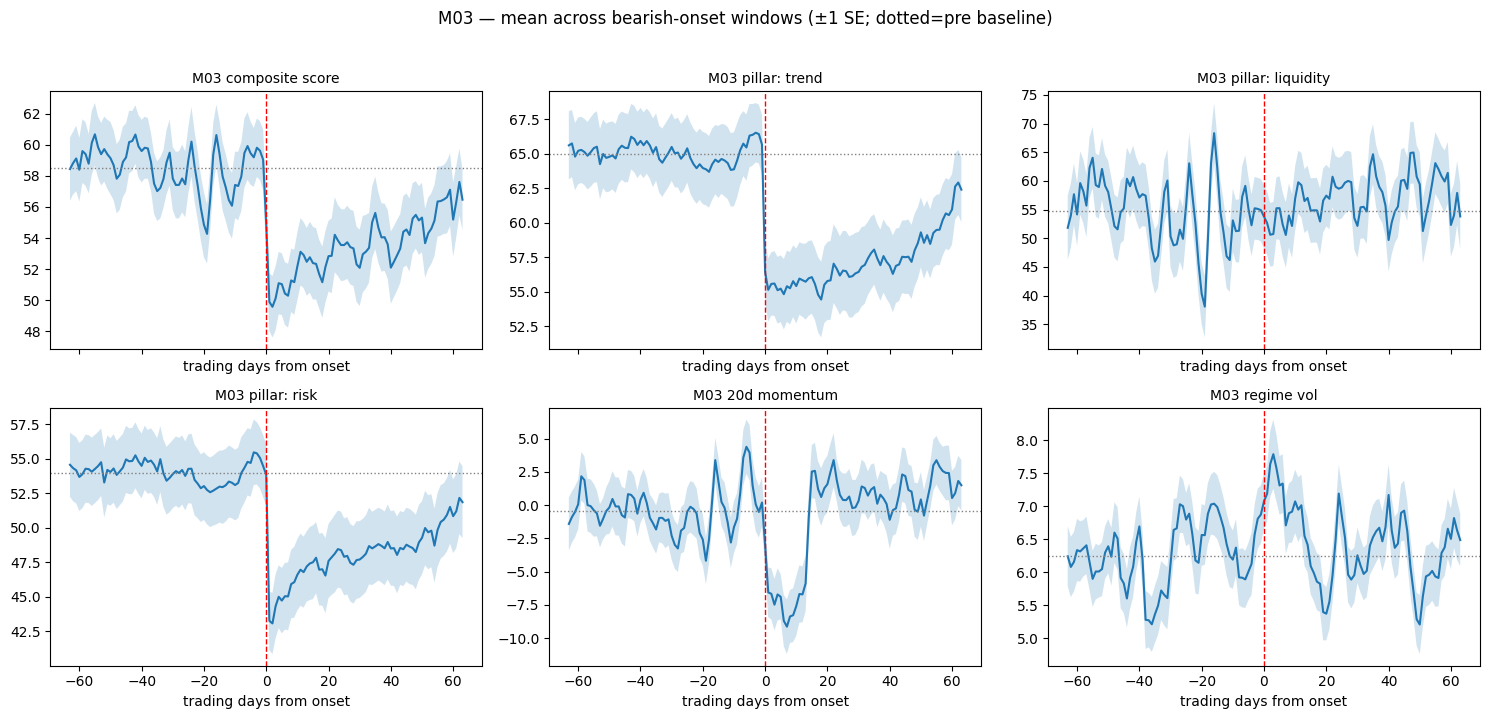

In [15]:
# %%  M03 — pillar/indicator event study
M03 = {
    "m03_score":        "composite score",
    "m03_pillar_trend": "pillar: trend",
    "m03_pillar_liq":   "pillar: liquidity",
    "m03_pillar_risk":  "pillar: risk",
    "m03_delta_20d":    "20d momentum",
    "m03_regime_vol":   "regime vol",
}
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for ax, (col, title) in zip(axes.ravel(), M03.items()):
    p = event_profile(col)
    ax.plot(p.offset, p.m, lw=1.5)
    ax.fill_between(p.offset, p.m - p.se, p.m + p.se, alpha=.20)
    base = p.loc[p.offset.between(-PRE, -6), "m"].mean()      # pre-window baseline band
    ax.axhline(base, color="grey", ls=":", lw=1)
    ax.axvline(0, color="r", ls="--", lw=1)
    ax.set_title(f"M03 {title}", fontsize=10)
    ax.set_xlabel("trading days from onset")
fig.suptitle("M03 — mean across bearish-onset windows (±1 SE; dotted=pre baseline)", y=1.02)
plt.tight_layout(); plt.show()


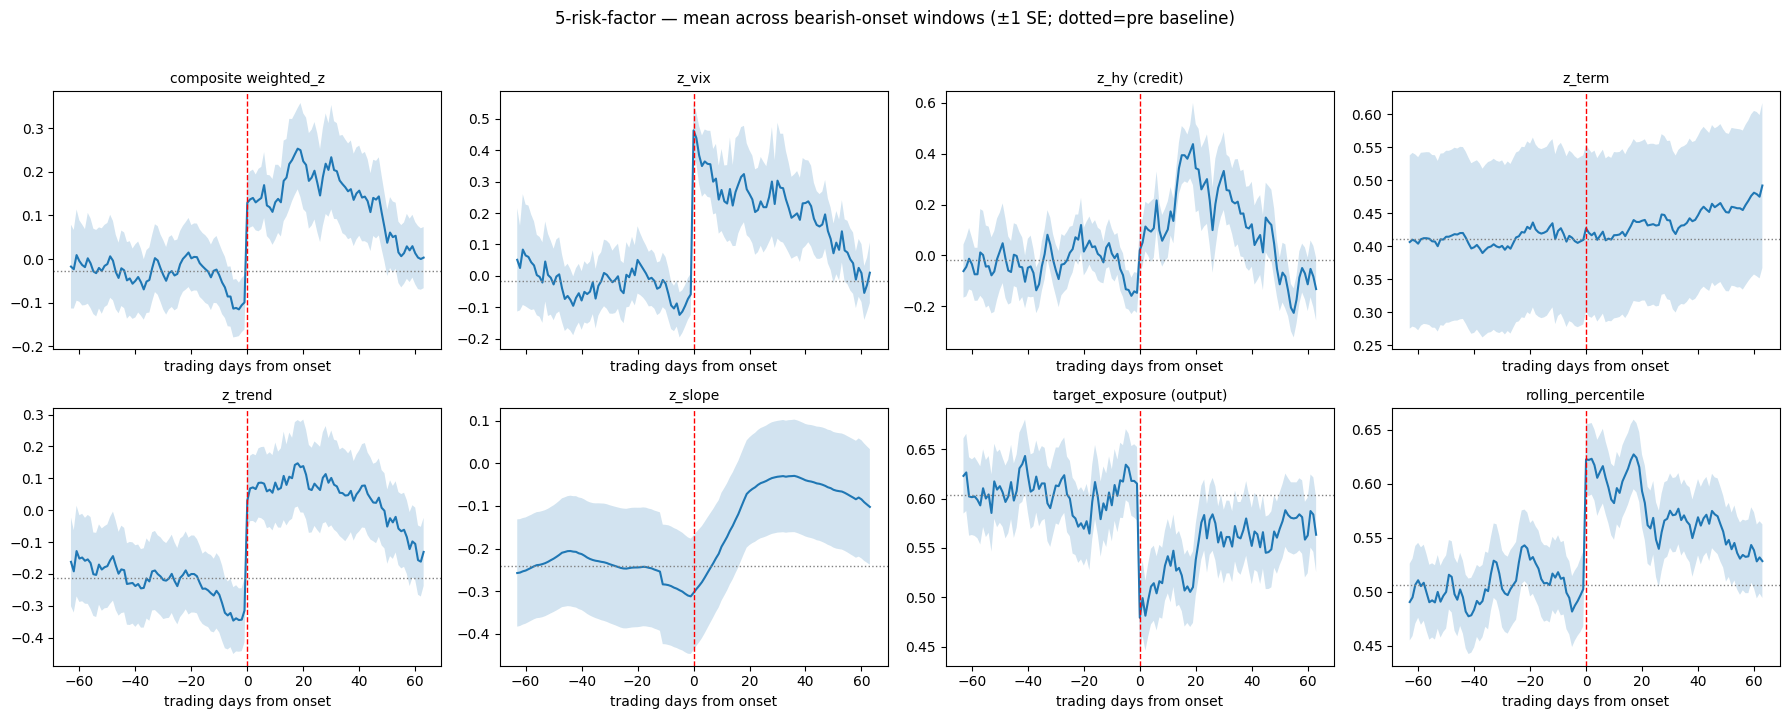

indicator                   PRE    EVENT     POST  lead?(-10..-1 vs PRE)
m03_score                58.525   54.879   53.788                 0.3974
m03_pillar_trend         64.959   60.397   57.404                 0.6544
m03_pillar_liq           54.770   53.733   57.310                -0.2892
m03_pillar_risk          53.966   49.934   48.412                 0.4849
m03_delta_20d            -0.475   -2.929   -0.135                 1.6010
m03_regime_vol            6.243    7.000    6.330                 0.0280
weighted_z               -0.027    0.024    0.134                -0.0611
z_vix                    -0.017    0.172    0.190                -0.0665
z_hy                     -0.017   -0.021    0.124                -0.0673
z_term                    0.412    0.414    0.444                 0.0021
z_trend                  -0.213   -0.117    0.035                -0.1097
z_slope                  -0.240   -0.293   -0.080                -0.0573
target_exposure           0.604    0.554    0.556  

In [16]:
# %%  5-risk-factor — per-indicator event study (z_* are the standardized signals)
RISK = {
    "weighted_z":      "composite weighted_z",
    "z_vix":           "z_vix",
    "z_hy":            "z_hy (credit)",
    "z_term":          "z_term",
    "z_trend":         "z_trend",
    "z_slope":         "z_slope",
    "target_exposure": "target_exposure (output)",
    "rolling_percentile": "rolling_percentile",
}
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, (col, title) in zip(axes.ravel(), RISK.items()):
    p = event_profile(col)
    ax.plot(p.offset, p.m, lw=1.5)
    ax.fill_between(p.offset, p.m - p.se, p.m + p.se, alpha=.20)
    base = p.loc[p.offset.between(-PRE, -6), "m"].mean()
    ax.axhline(base, color="grey", ls=":", lw=1)
    ax.axvline(0, color="r", ls="--", lw=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("trading days from onset")
fig.suptitle("5-risk-factor — mean across bearish-onset windows (±1 SE; dotted=pre baseline)", y=1.02)
plt.tight_layout(); plt.show()

# numeric lead test: pre-window swing per indicator. A real LEAD = the band departs
# from the dotted pre-baseline BEFORE offset 0, not at/after it.
print(f"{'indicator':22s} {'PRE':>8s} {'EVENT':>8s} {'POST':>8s} {'lead?(-10..-1 vs PRE)':>22s}")
for col in [*M03, *RISK]:
    p = event_profile(col).set_index("offset")["m"]
    pre   = p.loc[-PRE:-6].mean()
    early = p.loc[-10:-1].mean()      # last 2 weeks BEFORE onset
    evt   = p.loc[-5:5].mean()
    post  = p.loc[6:POST].mean()
    lead  = early - pre               # nonzero & same sign as event-swing = candidate lead
    print(f"{col:22s} {pre:8.3f} {evt:8.3f} {post:8.3f} {lead:22.4f}")


#### Control

In [17]:
# %%  Control sets for calibration
# Three references, computed on the SAME panel used for the event study:
#   ALL  = unconditional baseline (every day) — the HONEST "normal" (do NOT use far-from-event;
#          excluding +/-63d around 80 onsets leaves only ~171 deep-bull days -> survivorship trap)
#   JUMP = the bottom-5% return days themselves — the coincident reference
#   The event-study PRE band already lives in event_profile(); we just z-score it vs ALL.
cut_ret = bench["ret"].quantile(BEAR_Q)
jump_i  = set(bench.loc[bench["ret"] <= cut_ret, "i"])

def ref_stats(col):
    s = panel.set_index("i")[col]
    allv  = s.dropna()
    jumpv = s.loc[s.index.isin(jump_i)].dropna()
    return dict(all_mean=allv.mean(), all_std=allv.std(),
                jump_mean=jumpv.mean())

# guard against the trap, in case anyone recomputes a "normal" set later
def normal_far_from_event(half=63):
    near = set()
    for i0 in onset.i0:
        near.update(range(i0-half, i0+half+1))
    far = set(panel.dropna(subset=["m03_score"]).i) - near
    if len(far) < 250:
        raise ValueError(f"far-from-event set too small (n={len(far)}) — use unconditional baseline instead")
    return far


In [18]:
# %%  Calibration table — is the score elevated vs a NORMAL day, and WHEN?
PRE_LO, PRE_HI   = -PRE, -6      # quarter-ahead window
EARLY_LO, EARLY_HI = -10, -1     # last 2 weeks before onset (the real "lead" test)

def windowed_mean(col, lo, hi):
    s = panel.set_index("i")[col]
    idx = [e.i0 + off for e in onset.itertuples() for off in range(lo, hi+1)]
    return s.reindex(idx).mean()      # reindex -> NaN for missing; .mean() skips NaN

rows = []
for col in [*M03, *RISK]:               # reuse the dicts from the M03/RISK plot cells
    r = ref_stats(col); sd = r["all_std"] or np.nan
    z = lambda x: (x - r["all_mean"]) / sd
    rows.append(dict(
        indicator=col,
        normal=round(r["all_mean"], 3),
        pre_z=round(z(windowed_mean(col, PRE_LO, PRE_HI)), 2),
        early_z=round(z(windowed_mean(col, EARLY_LO, EARLY_HI)), 2),   # <-- lead lives here
        jump_z=round(z(r["jump_mean"]), 2),
    ))
calib = pd.DataFrame(rows)
# |early_z| > ~1 AND same sign as jump_z would be a genuine lead. Expect all ~0.
calib


,indicator,normal,pre_z,early_z,jump_z
0,m03_score,58.745,-0.01,0.01,-1.00
1,m03_pillar_trend,64.125,0.04,0.07,-1.19
2,m03_pillar_liq,55.752,-0.02,-0.03,-0.13
3,m03_pillar_risk,54.861,-0.04,-0.02,-0.79
4,m03_delta_20d,-0.159,-0.02,0.08,-0.60
5,m03_regime_vol,6.333,-0.02,-0.02,0.21
6,weighted_z,-0.028,0.00,-0.09,1.12
7,z_vix,-0.061,0.05,-0.02,1.53
8,z_hy,-0.001,-0.02,-0.09,0.61
9,z_term,0.499,-0.08,-0.08,0.10


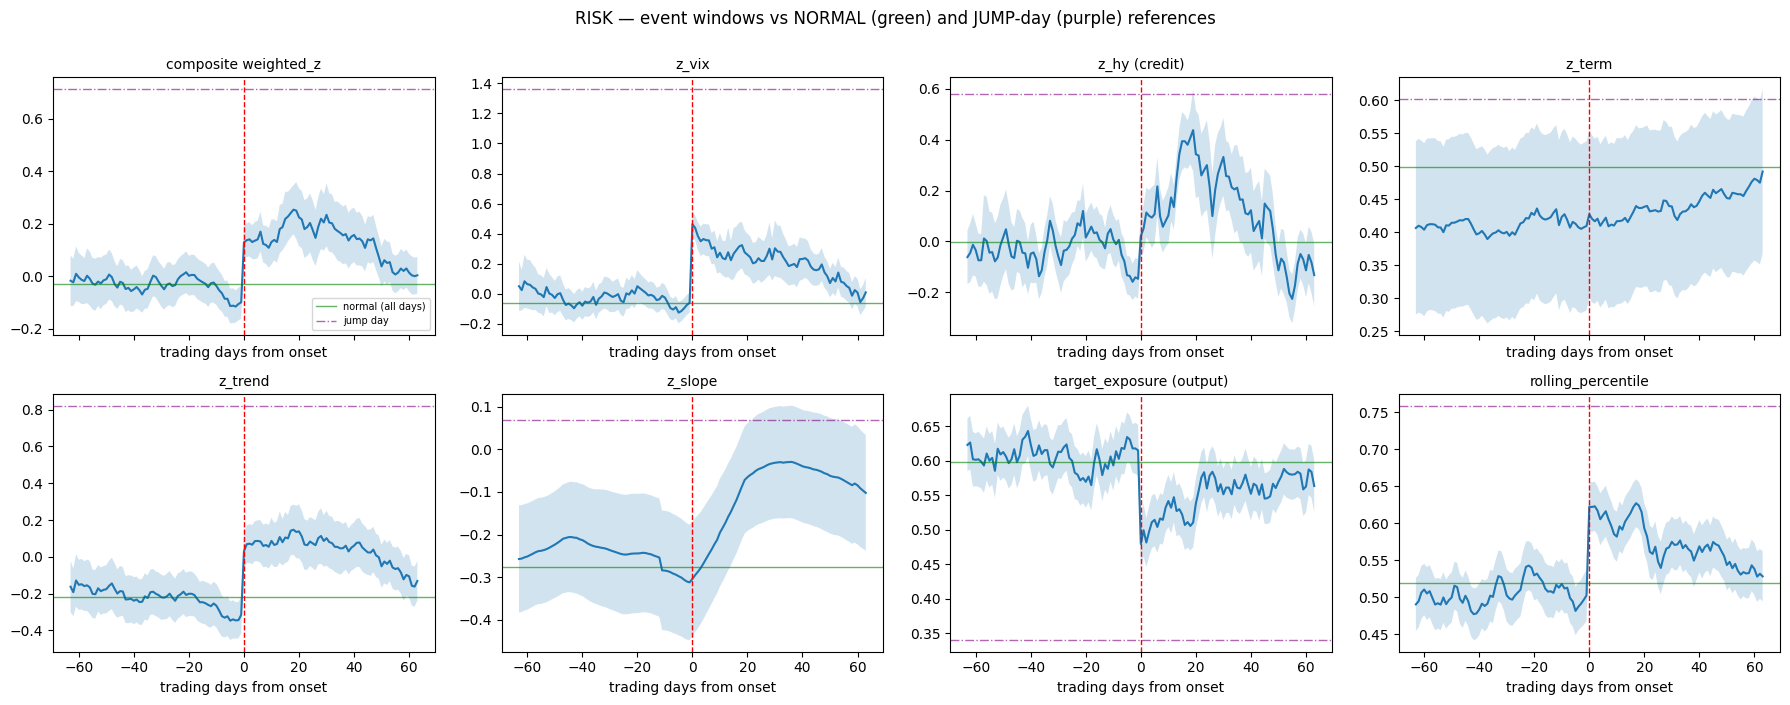

In [19]:
# %%  Re-plot one model with calibration overlay (swap M03 <-> RISK as needed)
GROUP = RISK            # or M03
nrow = (len(GROUP)+3)//4
fig, axes = plt.subplots(nrow, 4, figsize=(18, 3.5*nrow), sharex=True)
for ax, (col, title) in zip(axes.ravel(), GROUP.items()):
    p = event_profile(col); r = ref_stats(col)
    ax.plot(p.offset, p.m, lw=1.5)
    ax.fill_between(p.offset, p.m-p.se, p.m+p.se, alpha=.20)
    ax.axhline(r["all_mean"],  color="green", ls="-",  lw=1, alpha=.6, label="normal (all days)")
    ax.axhline(r["jump_mean"], color="purple",ls="-.", lw=1, alpha=.6, label="jump day")
    ax.axvline(0, color="r", ls="--", lw=1)
    ax.set_title(title, fontsize=10); ax.set_xlabel("trading days from onset")
axes.ravel()[0].legend(fontsize=7, loc="best")
fig.suptitle(f"{'RISK' if GROUP is RISK else 'M03'} — event windows vs NORMAL (green) and JUMP-day (purple) references", y=1.0)
plt.tight_layout(); plt.show()


#### 2-axis regime view, PCA & clustering, weight audit

In [20]:
reg=con.execute("select * from t2_regime_scores").df(); reg["date"]=pd.to_datetime(reg["date"])
rsk=con.execute("select * from t2_risk_scores").df(); rsk["date"]=pd.to_datetime(rsk["date"])
px =con.execute("select date,close from price_data where ticker=? and date>=? order by date",[BENCH,START]).df()
px["date"]=pd.to_datetime(px["date"])
df=px.merge(reg,on="date").merge(rsk,on="date").sort_values("date").reset_index(drop=True)
df["ret"]=df["close"].pct_change()
df["fvol"]=df["ret"].shift(-1).rolling(5).std().shift(-4)*np.sqrt(252)   # 5d ann fwd realized vol
df["f21"]=df["close"].shift(-21)/df["close"]-1
FACS=["z_vix","z_hy","z_term","z_trend","z_slope","m03_pillar_liq","m03_pillar_trend"]

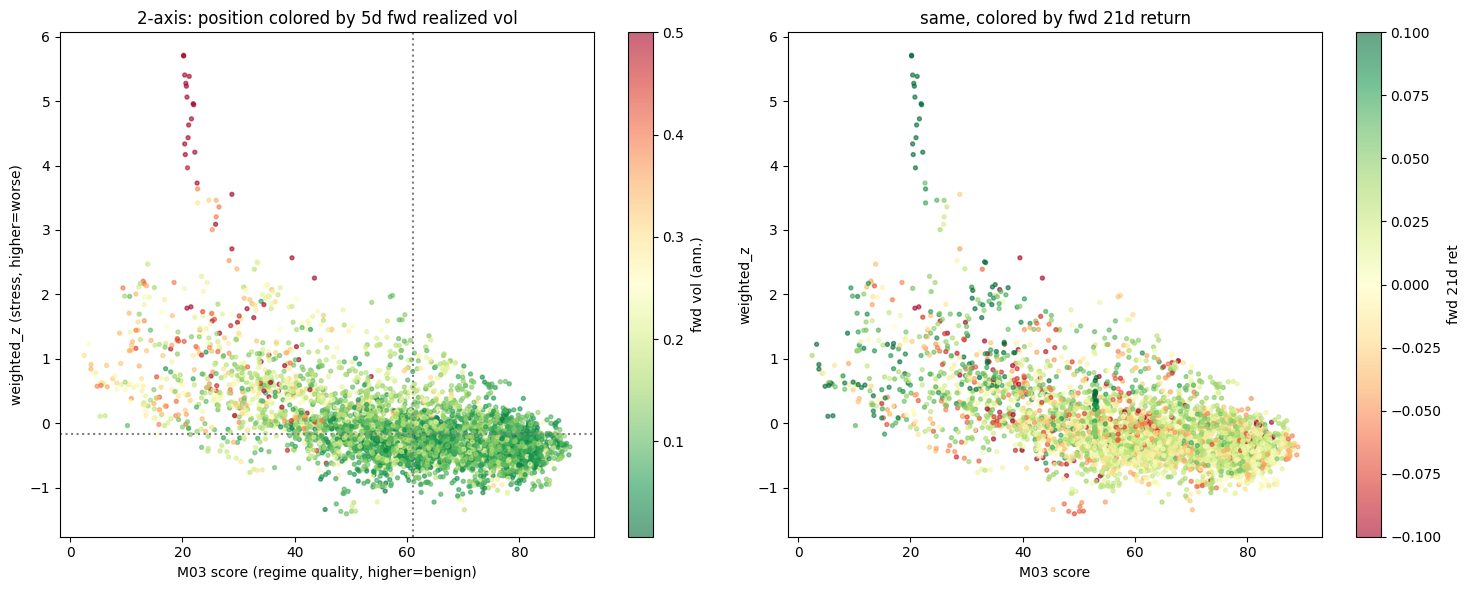

In [21]:
fig,ax=plt.subplots(1,2,figsize=(15,6))
sc=ax[0].scatter(df.m03_score,df.weighted_z,c=df.fvol,cmap="RdYlGn_r",s=8,alpha=.6,vmax=0.5)
ax[0].set(xlabel="M03 score (regime quality, higher=benign)",ylabel="weighted_z (stress, higher=worse)",
          title="2-axis: position colored by 5d fwd realized vol")
plt.colorbar(sc,ax=ax[0],label="fwd vol (ann.)")
# off-diagonal = disagreement. annotate the two interesting corners
ax[0].axhline(df.weighted_z.median(),color="grey",ls=":"); ax[0].axvline(df.m03_score.median(),color="grey",ls=":")
sc2=ax[1].scatter(df.m03_score,df.weighted_z,c=df.f21,cmap="RdYlGn",s=8,alpha=.6,vmin=-.1,vmax=.1)
ax[1].set(xlabel="M03 score",ylabel="weighted_z",title="same, colored by fwd 21d return")
plt.colorbar(sc2,ax=ax[1],label="fwd 21d ret")
plt.tight_layout(); plt.show()

In [22]:
from numpy.linalg import lstsq
def r2(cols,tgt):
    s=df[cols+[tgt]].dropna(); X=np.column_stack([np.ones(len(s))]+[s[c].values for c in cols])
    b=lstsq(X,s[tgt].values,rcond=None)[0]; p=X@b
    return 1-((s[tgt].values-p)**2).sum()/((s[tgt].values-s[tgt].mean())**2).sum()
df["interact"]=df.m03_score*df.weighted_z
for t in ["fvol","f21"]:
    print(t, "m03",round(r2(['m03_score'],t),4),"| wz",round(r2(['weighted_z'],t),4),
          "| both",round(r2(['m03_score','weighted_z'],t),4),
          "| +interact",round(r2(['m03_score','weighted_z','interact'],t),4))
# fvol: m03 0.20 | wz 0.32 | both 0.34 | +interact 0.35  -> 2nd axis adds ~0.02-0.04 R2. Small but real.

fvol m03 0.2436 | wz 0.327 | both 0.3689 | +interact 0.3976
f21 m03 0.0178 | wz 0.0366 | both 0.0375 | +interact 0.0468


explained var: [0.455 0.178 0.134 0.106 0.073 0.044 0.009]
                   PC1   PC2   PC3
z_vix             0.40  0.28 -0.15
z_hy              0.27  0.47 -0.10
z_term            0.21 -0.61  0.36
z_trend           0.54 -0.03  0.01
z_slope           0.44 -0.33  0.21
m03_pillar_liq   -0.03  0.45  0.88
m03_pillar_trend -0.49 -0.12  0.11


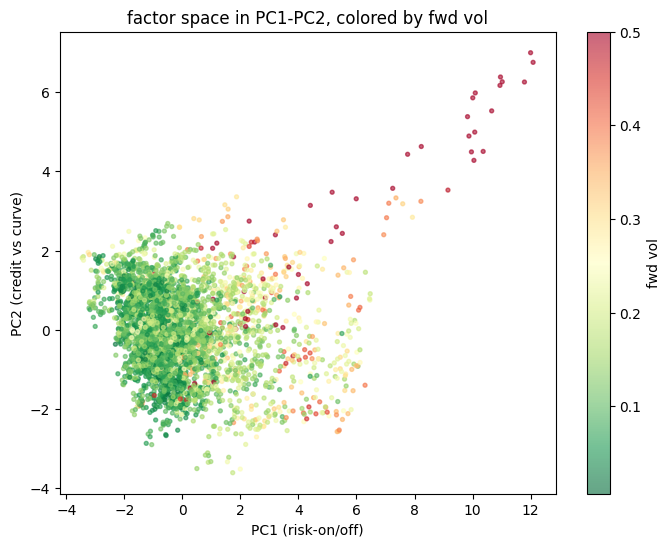

In [23]:
F=df[FACS].dropna(); Fz=(F-F.mean())/F.std()
U,S,Vt=np.linalg.svd(Fz.values,full_matrices=False); evr=S**2/(S**2).sum()
print("explained var:",np.round(evr,3))   # [0.46 0.18 0.13 0.11 0.07 0.04 0.01]
load=pd.DataFrame(Vt[:3].T,index=FACS,columns=["PC1","PC2","PC3"]).round(2); print(load)
# PC1 = broad risk-on/off (vix+trend+slope). PC2 = credit-vs-curve. PC3 = ALMOST PURE net-liquidity (0.88).
# project & color by fwd vol
sc=df.dropna(subset=FACS).copy()
P=(sc[FACS]-F.mean())/F.std()
sc["pc1"]=P.values@Vt[0]; sc["pc2"]=P.values@Vt[1]
plt.figure(figsize=(8,6))
plt.scatter(sc.pc1,sc.pc2,c=sc.fvol,cmap="RdYlGn_r",s=8,alpha=.6,vmax=.5)
plt.colorbar(label="fwd vol"); plt.xlabel("PC1 (risk-on/off)"); plt.ylabel("PC2 (credit vs curve)")
plt.title("factor space in PC1-PC2, colored by fwd vol"); plt.show()

In [24]:
from sklearn.cluster import KMeans
sc=df.dropna(subset=FACS+["fvol","f21"]).copy()
Fz=(sc[FACS]-sc[FACS].mean())/sc[FACS].std()
sc["clu"]=KMeans(4,n_init=10,random_state=0).fit_predict(Fz.values)
print(sc.groupby("clu").agg(n=("ret","size"),z_vix=("z_vix","mean"),z_trend=("z_trend","mean"),
    liq=("m03_pillar_liq","mean"),fwd_vol=("fvol","mean"),fwd21=("f21","mean")).round(3))
# clu interpretation (typical run):
#  0 calm/weak-trend low-liq | 1 risk-OFF high-vol | 2 calm high-liq (best fwd) | 3 CRISIS (n~29, Mar2020, fwd_vol .72)

        n  z_vix  z_trend      liq  fwd_vol  fwd21
clu                                               
0    1461 -0.322   -0.492    4.325    0.117  0.007
1     720  0.956    1.187   50.995    0.230  0.020
2    1909 -0.336   -0.589   96.349    0.109  0.012
3      29  5.990    3.699  100.000    0.727  0.087


In [25]:
# WRONG WAY (do not use): mean(|f_*|) — f_vix is raw VIX spot (~9-82) vs f_trend (~0.04),
# so |f_vix| dominates purely on UNITS. That is NOT a weight. The model z-scores first.
W={"z_vix":0.25,"z_hy":0.25,"z_term":0.15,"z_trend":0.15,"z_slope":0.20}   # src/pipeline/risk_5_factor.py:40
d=rsk.dropna(subset=list(W))
recon=sum(d[c]*w for c,w in W.items())
print("weighted_z reconstruct corr:",round(recon.corr(d.weighted_z),4))   # 1.0 exact -> code is correct
# proper variance-share of each weighted term in weighted_z:
vw=d.weighted_z.var()
for c,w in W.items():
    share=np.cov(d[c]*w,d.weighted_z)[0,1]/vw
    print(f"  {c:8s} var-share {share*100:5.1f}%")
# RESULT: z_vix 29.5 | z_hy 24.8 | z_slope 21.7 | z_trend 19.1 | z_term 4.9  -> BALANCED, not VIX-only.
# 'looks like just VIX' = factor co-movement in stress (z_trend corr w/ wz 0.87 > z_vix 0.78), not weighting.
# Only genuine takeaway: z_term contributes 4.9% -> near-inert, candidate to drop/re-spec.

weighted_z reconstruct corr: 1.0
  z_vix    var-share  29.5%
  z_hy     var-share  24.8%
  z_term   var-share   4.9%
  z_trend  var-share  19.1%
  z_slope  var-share  21.7%


In [26]:
con.close()